# 04 — Modélisation & Entraînement

**Objectif** : Entraîner, comparer et sélectionner le meilleur modèle de classification de la qualité radio UMTS.

**Modèles** :
- Logistic Regression (baseline linéaire)
- Random Forest (ensemble arbre)
- XGBoost / GradientBoosting (boosting)

**Métriques** : Accuracy, Precision, Recall, F1, ROC-AUC

In [1]:
RUN_INSTALL = False
if RUN_INSTALL:
    import subprocess, sys
    pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "joblib", "xgboost"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import warnings
from pathlib import Path
from time import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# XGBoost optionnel — fallback sur GradientBoosting
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost disponible")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost non installé — GradientBoosting sklearn utilisé à la place")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NOTEBOOK_DIR = Path().resolve()
DATA_DIR     = NOTEBOOK_DIR / "data"
PREP_DIR     = DATA_DIR / "data_prepared"
MODEL_DIR    = NOTEBOOK_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Lecture  : {PREP_DIR}")
print(f"Modèles  : {MODEL_DIR}")

⚠️  XGBoost non installé — GradientBoosting sklearn utilisé à la place
Lecture  : C:\projet ingeneurie des réseaux\notebooks\data\data_prepared
Modèles  : C:\projet ingeneurie des réseaux\notebooks\models


## 2. Chargement des données préparées

In [4]:
X_train = np.load(PREP_DIR / "X_train.npy")
X_val   = np.load(PREP_DIR / "X_val.npy")
X_test  = np.load(PREP_DIR / "X_test.npy")
y_train = np.load(PREP_DIR / "y_train.npy").astype(int)
y_val   = np.load(PREP_DIR / "y_val.npy").astype(int)
y_test  = np.load(PREP_DIR / "y_test.npy").astype(int)

# Charger les noms de features si disponibles
feat_names_path = PREP_DIR / "feature_names.csv"
if feat_names_path.exists():
    feature_names = pd.read_csv(feat_names_path)["feature"].tolist()
else:
    feature_names = [f"f_{i}" for i in range(X_train.shape[1])]

# Charger métadonnées
meta_path = PREP_DIR / "metadata.json"
if meta_path.exists():
    with open(meta_path) as f:
        meta = json.load(f)
    print("Métadonnées chargées :", json.dumps({k: v for k, v in meta.items() if k != "num_features"}, indent=2))

print(f"\n── Shapes ──")
print(f"  X_train : {X_train.shape}  y_train : {np.bincount(y_train)}")
print(f"  X_val   : {X_val.shape}  y_val   : {np.bincount(y_val)}")
print(f"  X_test  : {X_test.shape}  y_test  : {np.bincount(y_test)}")

Métadonnées chargées : {
  "n_train": 5825,
  "n_val": 1248,
  "n_test": 1249,
  "n_features": 37,
  "rscp_threshold": -85.0,
  "target_col": "target",
  "rscp_source_col": "rscp_active_1",
  "cat_features": []
}

── Shapes ──
  X_train : (5825, 37)  y_train : [2024 3801]
  X_val   : (1248, 37)  y_val   : [434 814]
  X_test  : (1249, 37)  y_test  : [434 815]


## 3. Définition des modèles

In [5]:
# ── Boosting : XGBoost ou GradientBoosting ────────────────────────────────────
if XGBOOST_AVAILABLE:
    boosting_model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
    )
    boosting_name = "XGBoost"
else:
    boosting_model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )
    boosting_name = "GradientBoosting"

MODELS = {
    "LogisticRegression": LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    boosting_name: boosting_model,
}

print("Modèles à entraîner :")
for name, model in MODELS.items():
    print(f"  - {name}: {model.__class__.__name__}")

Modèles à entraîner :
  - LogisticRegression: LogisticRegression
  - RandomForest: RandomForestClassifier
  - GradientBoosting: GradientBoostingClassifier


## 4. Entraînement avec Cross-Validation (sur Train)

In [6]:
def evaluate_model(model, X_eval, y_eval, prefix=""):
    """Calcule toutes les métriques de classification sur un jeu de données."""
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        f"{prefix}accuracy" : accuracy_score(y_eval, y_pred),
        f"{prefix}precision": precision_score(y_eval, y_pred, zero_division=0),
        f"{prefix}recall"   : recall_score(y_eval, y_pred, zero_division=0),
        f"{prefix}f1"       : f1_score(y_eval, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics[f"{prefix}roc_auc"] = roc_auc_score(y_eval, y_proba)

    return metrics, y_pred, y_proba

print("✅ Fonction evaluate_model définie")

✅ Fonction evaluate_model définie


In [7]:
# ── Cross-Validation 5-fold sur le TRAIN ─────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print("Cross-validation 5-fold (train uniquement)...")
print("-" * 60)

for name, model in MODELS.items():
    t0 = time()
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )
    elapsed = time() - t0
    cv_results[name] = {
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std" : scores.std(),
        "cv_time_s"      : elapsed,
    }
    print(f"  {name:<22} ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}  [{elapsed:.1f}s]")

print("-" * 60)

Cross-validation 5-fold (train uniquement)...
------------------------------------------------------------
  LogisticRegression     ROC-AUC = 0.9970 ± 0.0007  [2.9s]
  RandomForest           ROC-AUC = 0.9988 ± 0.0003  [3.1s]
  GradientBoosting       ROC-AUC = 0.9995 ± 0.0002  [6.8s]
------------------------------------------------------------


## 5. Entraînement final + évaluation sur Validation

In [8]:
trained_models = {}
val_results    = {}

print("Entraînement final + évaluation validation...")
print("-" * 60)

for name, model in MODELS.items():
    t0 = time()
    model.fit(X_train, y_train)
    elapsed = time() - t0
    trained_models[name] = model

    metrics, y_pred, y_proba = evaluate_model(model, X_val, y_val, prefix="val_")
    val_results[name] = {**metrics, "train_time_s": elapsed}

    print(f"  {name:<22} | Acc={metrics['val_accuracy']:.3f} | "
          f"F1={metrics['val_f1']:.3f} | "
          f"AUC={metrics.get('val_roc_auc', float('nan')):.3f} | "
          f"[{elapsed:.1f}s]")

print("-" * 60)

Entraînement final + évaluation validation...
------------------------------------------------------------
  LogisticRegression     | Acc=0.970 | F1=0.977 | AUC=0.997 | [0.0s]
  RandomForest           | Acc=0.987 | F1=0.990 | AUC=0.999 | [0.3s]
  GradientBoosting       | Acc=0.988 | F1=0.991 | AUC=1.000 | [5.4s]
------------------------------------------------------------


## 6. Tableau de comparaison des modèles

In [9]:
# Assembler les résultats dans un DataFrame clair
rows = []
for name in MODELS:
    row = {"Model": name}
    row["CV ROC-AUC"] = f"{cv_results[name]['cv_roc_auc_mean']:.4f} ± {cv_results[name]['cv_roc_auc_std']:.4f}"
    m = val_results[name]
    row["Val Accuracy"]  = round(m["val_accuracy"],  4)
    row["Val Precision"] = round(m["val_precision"], 4)
    row["Val Recall"]    = round(m["val_recall"],    4)
    row["Val F1"]        = round(m["val_f1"],        4)
    row["Val ROC-AUC"]   = round(m.get("val_roc_auc", float("nan")), 4)
    row["Train Time (s)"]= round(m["train_time_s"],  2)
    rows.append(row)

df_results = pd.DataFrame(rows).set_index("Model")
print("── Tableau comparatif ──")
df_results

── Tableau comparatif ──


,CV ROC-AUC,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Train Time (s)
Model,,,,,,,
LogisticRegression,0.9970 ± 0.0007,0.9704,0.9767,0.9779,0.9773,0.9965,0.04
RandomForest,0.9988 ± 0.0003,0.9872,0.9807,1.0000,0.9903,0.9985,0.34
GradientBoosting,0.9995 ± 0.0002,0.9880,0.9854,0.9963,0.9908,0.9995,5.36


## 7. Visualisation comparative

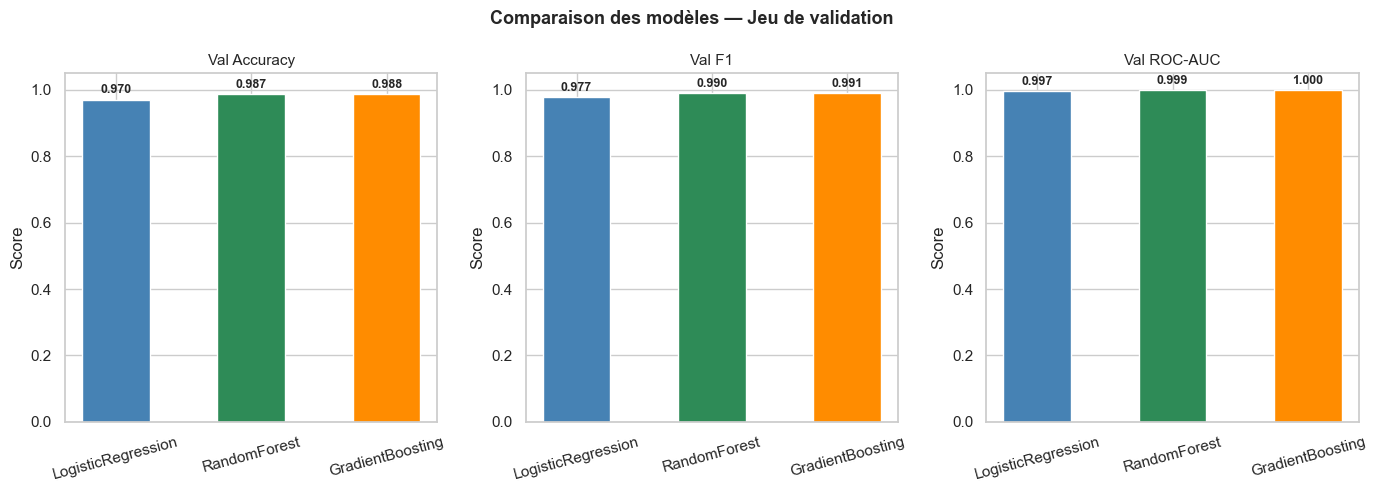

In [10]:
metrics_to_plot = ["Val Accuracy", "Val F1", "Val ROC-AUC"]
models_list     = list(MODELS.keys())
colors          = ["steelblue", "seagreen", "darkorange"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 5))

for ax, metric in zip(axes, metrics_to_plot):
    values = [df_results.loc[m, metric] for m in models_list]
    bars   = ax.bar(models_list, values, color=colors[:len(models_list)], edgecolor="white", width=0.5)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Comparaison des modèles — Jeu de validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

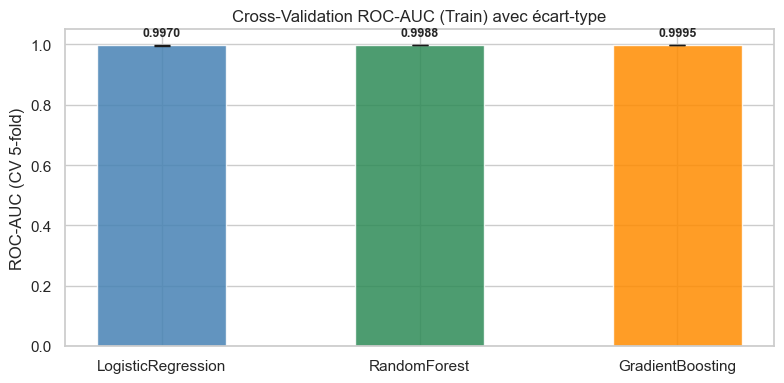

In [11]:
# CV ROC-AUC avec barres d'erreur
fig, ax = plt.subplots(figsize=(8, 4))
means = [cv_results[n]["cv_roc_auc_mean"] for n in models_list]
stds  = [cv_results[n]["cv_roc_auc_std"]  for n in models_list]

bars = ax.bar(models_list, means, yerr=stds, color=colors[:len(models_list)],
              edgecolor="white", capsize=6, width=0.5, alpha=0.85)
ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC (CV 5-fold)")
ax.set_title("Cross-Validation ROC-AUC (Train) avec écart-type")
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Matrices de confusion & Courbes ROC

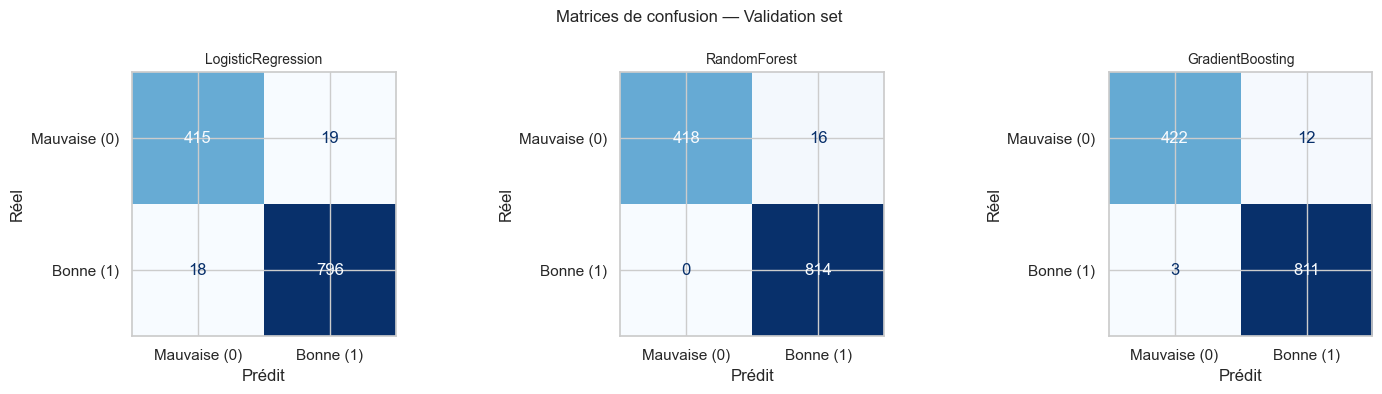

In [12]:
# Matrices de confusion sur validation
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 4))
if len(MODELS) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Mauvaise (0)", "Bonne (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.suptitle("Matrices de confusion — Validation set", fontsize=12)
plt.tight_layout()
plt.show()

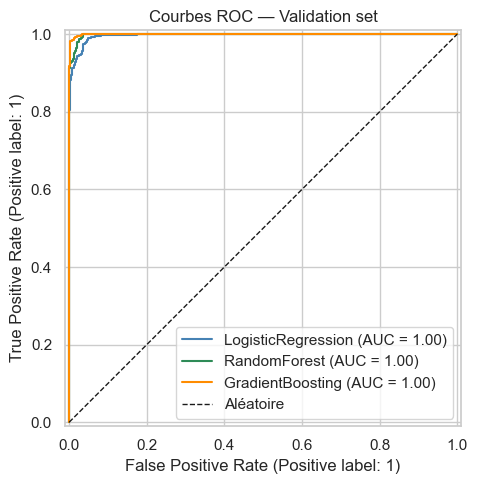

In [13]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 5))
colors_roc = ["steelblue", "seagreen", "darkorange"]

for color, (name, model) in zip(colors_roc, trained_models.items()):
    if hasattr(model, "predict_proba"):
        RocCurveDisplay.from_estimator(
            model, X_val, y_val, ax=ax, name=name, color=color
        )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Aléatoire")
ax.set_title("Courbes ROC — Validation set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Importance des features (meilleur modèle)

In [14]:
# Sélectionner le meilleur modèle basé sur Val ROC-AUC
best_model_name = df_results["Val ROC-AUC"].idxmax()
best_model      = trained_models[best_model_name]
print(f"🏆 Meilleur modèle : {best_model_name}")
print(f"   Val ROC-AUC : {df_results.loc[best_model_name, 'Val ROC-AUC']:.4f}")
print(f"   Val F1      : {df_results.loc[best_model_name, 'Val F1']:.4f}")

🏆 Meilleur modèle : GradientBoosting
   Val ROC-AUC : 0.9995
   Val F1      : 0.9908


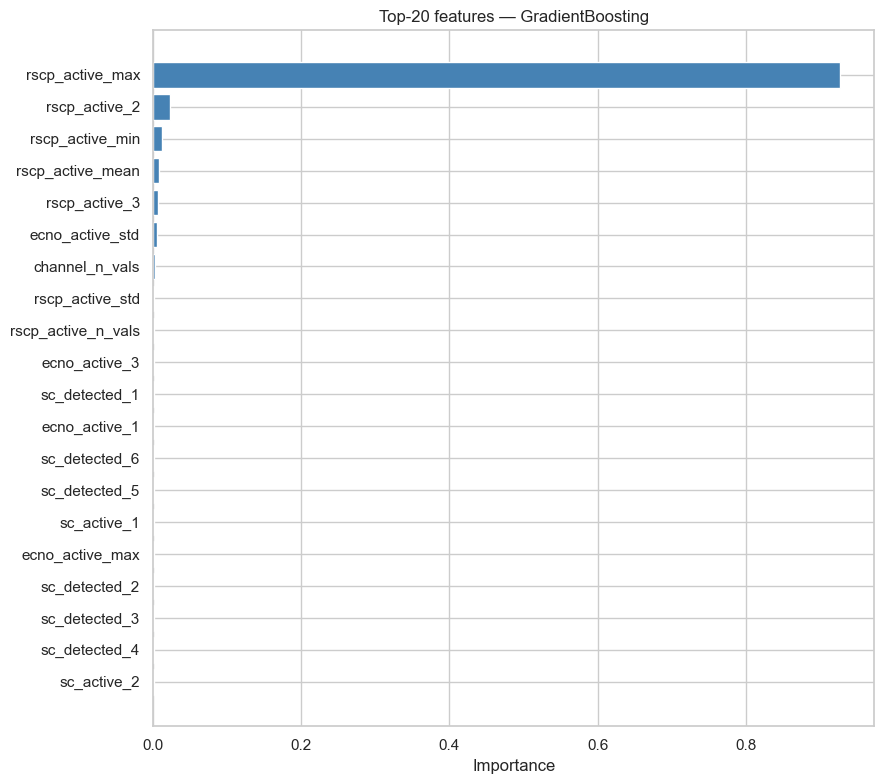


Top 10 features :
           feature  importance
   rscp_active_max    0.926993
     rscp_active_2    0.022032
   rscp_active_min    0.012048
  rscp_active_mean    0.007306
     rscp_active_3    0.006994
   ecno_active_std    0.005407
    channel_n_vals    0.001620
   rscp_active_std    0.001514
rscp_active_n_vals    0.001426
     ecno_active_3    0.001419


In [15]:
# Feature importance (si disponible)
importances = None

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])

if importances is not None and len(feature_names) == len(importances):
    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    top_n = min(20, len(fi_df))
    fig, ax = plt.subplots(figsize=(9, top_n * 0.35 + 1))
    fi_top = fi_df.head(top_n).iloc[::-1]  # Inverser pour barh
    ax.barh(fi_top["feature"], fi_top["importance"], color="steelblue", edgecolor="white")
    ax.set_xlabel("Importance")
    ax.set_title(f"Top-{top_n} features — {best_model_name}")
    plt.tight_layout()
    plt.show()

    print(f"\nTop 10 features :")
    print(fi_df.head(10).to_string(index=False))
else:
    print(f"⚠️  Feature importance non disponible ou noms de features désalignés")
    print(f"   len(feature_names)={len(feature_names)}, len(importances)={len(importances) if importances is not None else 'N/A'}")

## 10. Évaluation finale sur le Test set

⚠️ Cette cellule est exécutée **une seule fois** avec le meilleur modèle — pas de re-tuning après.

In [16]:
print("=" * 55)
print(f" ÉVALUATION FINALE — {best_model_name} — TEST SET")
print("=" * 55)

test_metrics, y_test_pred, y_test_proba = evaluate_model(best_model, X_test, y_test, prefix="test_")

for k, v in test_metrics.items():
    print(f"  {k:<20} : {v:.4f}")

print("\n── Rapport classification détaillé ──")
print(classification_report(y_test, y_test_pred, target_names=["Mauvaise qualité", "Bonne qualité"]))

 ÉVALUATION FINALE — GradientBoosting — TEST SET
  test_accuracy        : 0.9864
  test_precision       : 0.9854
  test_recall          : 0.9939
  test_f1              : 0.9896
  test_roc_auc         : 0.9995

── Rapport classification détaillé ──
                  precision    recall  f1-score   support

Mauvaise qualité       0.99      0.97      0.98       434
   Bonne qualité       0.99      0.99      0.99       815

        accuracy                           0.99      1249
       macro avg       0.99      0.98      0.98      1249
    weighted avg       0.99      0.99      0.99      1249



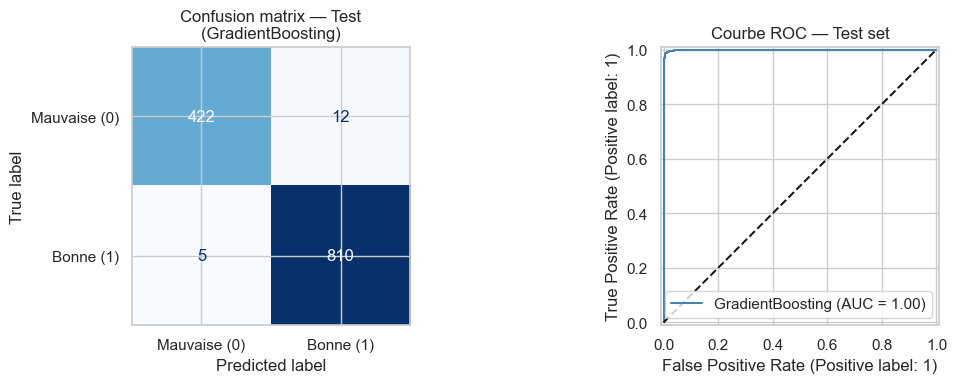

In [17]:
# Matrice de confusion test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=["Mauvaise (0)", "Bonne (1)"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title(f"Confusion matrix — Test\n({best_model_name})")

# Courbe ROC test
if y_test_proba is not None:
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1], name=best_model_name, color="steelblue")
    axes[1].plot([0, 1], [0, 1], "k--")
    axes[1].set_title("Courbe ROC — Test set")
else:
    axes[1].text(0.5, 0.5, "predict_proba non disponible", ha="center")

plt.tight_layout()
plt.show()

## 11. Sauvegarde du meilleur modèle

In [ ]:
# Sauvegarder le meilleur modèle
model_path = MODEL_DIR / f"best_model_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_model, model_path)
print(f" Meilleur modèle sauvegardé : {model_path}")

# Sauvegarder tous les modèles
for name, model in trained_models.items():
    p = MODEL_DIR / f"model_{name.lower().replace(' ', '_')}.pkl"
    joblib.dump(model, p)
    print(f"   Sauvegardé : {p.name}")

# Sauvegarder le résumé des résultats
results_path = MODEL_DIR / "model_comparison.csv"
df_results.to_csv(results_path)
print(f"\n Comparaison sauvegardée : {results_path}")

# Sauvegarder les métriques test du meilleur modèle
final_meta = {
    "best_model": best_model_name,
    "test_metrics": {k: round(v, 4) for k, v in test_metrics.items()},
    "val_roc_auc": round(df_results.loc[best_model_name, "Val ROC-AUC"], 4),
    "model_path": str(model_path),
}
with open(MODEL_DIR / "best_model_meta.json", "w") as f:
    json.dump(final_meta, f, indent=2)

print(f"\n── Fichiers dans models/ ──")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"   {f.name:<50} {f.stat().st_size/1024:>8.1f} KB")

✅ Meilleur modèle sauvegardé : C:\projet ingeneurie des réseaux\notebooks\models\best_model_gradientboosting.pkl
   Sauvegardé : model_logisticregression.pkl
   Sauvegardé : model_randomforest.pkl
   Sauvegardé : model_gradientboosting.pkl

✅ Comparaison sauvegardée : C:\projet ingeneurie des réseaux\notebooks\models\model_comparison.csv

── Fichiers dans models/ ──
   best_model_gradientboosting.pkl                       698.9 KB
   best_model_meta.json                                    0.3 KB
   model_comparison.csv                                    0.3 KB
   model_gradientboosting.pkl                            698.9 KB
   model_logisticregression.pkl                            1.1 KB
   model_randomforest.pkl                               2647.6 KB


## 12. Récapitulatif final

In [ ]:
print("╔" + "═" * 53 + "╗")
print("║          RÉCAPITULATIF PROJET ML UMTS              ║")
print("╠" + "═" * 53 + "╣")
print(f"║  Données : {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]:>6} mesures radio UMTS{' '*22}║")
print(f"║  Features : {X_train.shape[1]:>5} après feature engineering{' '*14}║")
print("║  Cible   : qualité radio (RSCP ≥ -85 dBm = OK)    ║")
print("╠" + "═" * 53 + "╣")
print("║  Modèles évalués :                                 ║")
for name in MODELS:
    mark = " ***" if name == best_model_name else "   "
    auc  = df_results.loc[name, "Val ROC-AUC"]
    f1   = df_results.loc[name, "Val F1"]
    print(f"║  {mark} {name:<22} AUC={auc:.3f} F1={f1:.3f}  ║")
print("╠" + "═" * 53 + "╣")
print(f"║  Meilleur modèle : {best_model_name:<34}║")
print(f"║  Test ROC-AUC    : {test_metrics.get('test_roc_auc', float('nan')):.4f}{' '*28}║")
print(f"║  Test F1         : {test_metrics.get('test_f1', float('nan')):.4f}{' '*28}║")
print(f"║  Test Accuracy   : {test_metrics.get('test_accuracy', float('nan')):.4f}{' '*28}║")
print("╚" + "═" * 53 + "╝")

╔═════════════════════════════════════════════════════╗
║          RÉCAPITULATIF PROJET ML UMTS              ║
╠═════════════════════════════════════════════════════╣
║  Données :   8322 mesures radio UMTS                      ║
║  Features :    37 après feature engineering              ║
║  Cible   : qualité radio (RSCP ≥ -85 dBm = OK)    ║
╠═════════════════════════════════════════════════════╣
║  Modèles évalués :                                 ║
║      LogisticRegression     AUC=0.997 F1=0.977  ║
║      RandomForest           AUC=0.999 F1=0.990  ║
║   🏆 GradientBoosting       AUC=1.000 F1=0.991  ║
╠═════════════════════════════════════════════════════╣
║  Meilleur modèle : GradientBoosting                  ║
║  Test ROC-AUC    : 0.9995                            ║
║  Test F1         : 0.9896                            ║
║  Test Accuracy   : 0.9864                            ║
╚═════════════════════════════════════════════════════╝


## 13. Checks de validation

In [ ]:
# ── Assertions finales ────────────────────────────────────────────────────────

# Tous les modèles entraînés
assert len(trained_models) == len(MODELS), "Tous les modèles n'ont pas été entraînés"

# Métriques dans les plages attendues
for name, model in trained_models.items():
    m, _, _ = evaluate_model(model, X_val, y_val, prefix="v_")
    assert 0.0 <= m["v_accuracy"] <= 1.0, f" Accuracy hors plage : {name}"
    assert 0.0 <= m["v_f1"] <= 1.0, f" F1 hors plage : {name}"

# Meilleur modèle sauvegardé et rechargeable
assert model_path.exists(), " Fichier modèle introuvable"
loaded_model = joblib.load(model_path)
y_reload_pred = loaded_model.predict(X_test[:10])
assert len(y_reload_pred) == 10, "Modèle rechargé ne produit pas 10 prédictions"
assert set(y_reload_pred).issubset({0, 1}), "Prédictions non binaires"

# Résultats csv sauvegardé
assert results_path.exists(), " Fichier comparaison introuvable"

# Performance minimale raisonnable
best_auc = test_metrics.get("test_roc_auc", 0)
assert best_auc > 0.55, f"  ROC-AUC test trop bas ({best_auc:.3f}) — vérifier les données"

print(f" Toutes assertions passées")
print(f"   Modèles entraînés : {list(trained_models.keys())}")
print(f"   Meilleur modèle   : {best_model_name}")
print(f"   Test ROC-AUC      : {best_auc:.4f}")
print(f"   Modèle rechargé   : OK — {len(y_reload_pred)} prédictions générées")
print("\n Projet ML UMTS complété avec succès !")

✅ Toutes assertions passées
   Modèles entraînés : ['LogisticRegression', 'RandomForest', 'GradientBoosting']
   Meilleur modèle   : GradientBoosting
   Test ROC-AUC      : 0.9995
   Modèle rechargé   : OK — 10 prédictions générées

🎉 Projet ML UMTS complété avec succès !
